In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import glob
import itertools
import numpy as np
import torch
from scipy.optimize import curve_fit
from scipy.stats import entropy, mannwhitneyu, wasserstein_distance
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from itertools import combinations

from src.models import expirimental_RNN
from src.datasets import NonstationaryRewardDelayDataset

In [2]:
def measure_impulse_time_constants(model, n_steps=2000, pulse_duration=5, pulse_amp=2.0, 
                                    min_response_thresh=0.01):
    model.eval()
    
    inputs = torch.zeros(1, n_steps, 1)
    inputs[0, :pulse_duration, 0] = pulse_amp

    h_trace = []
    with torch.no_grad():
        hidden = model.init_hidden(batch_size=1)
        for t in range(n_steps):
            inp_t = inputs[:, t:t+1, :]
            hidden, _ = model(inp_t, hidden, noise=False)
            h_trace.append(hidden.squeeze(0).numpy())

    h_trace = np.array(h_trace)        # (T, hidden_size)
    post_pulse = h_trace[pulse_duration:, :]
    t_axis = np.arange(len(post_pulse)) * model.dt

    def exp_decay(t, A, tau, C):
        return A * np.exp(-t / tau) + C

    taus = []
    for i in range(model.hidden_size):
        signal = post_pulse[:, i]
        amp = np.max(np.abs(signal))
        
        # Skip neurons that don't respond
        if amp < min_response_thresh:
            taus.append(np.nan)
            continue
        
        try:
            A0 = signal[0] - signal[-1]
            tau0 = t_axis[np.argmax(np.abs(signal - signal[-1]) < amp/np.e) + 1]  # 1/e crossing
            tau0 = max(tau0, model.dt)  # avoid zero
            p0 = [A0, tau0, signal[-1]]
            bounds = ([- np.inf, model.dt, -np.inf], [np.inf, t_axis[-1], np.inf])
            popt, _ = curve_fit(exp_decay, t_axis, signal, p0=p0, bounds=bounds, maxfev=10000)
            taus.append(abs(popt[1]))
        except (RuntimeError, ValueError):
            taus.append(np.nan)

    return np.array(taus), h_trace

In [3]:
# Load weights

results_dir = '../rnn_results/final/'

all_dirs = glob.glob(results_dir + 'autocorr*_ktau*_zeroint*_delay*_normal_eta*')

found_autocorrs = {f.split('autocorr')[-1].split('_')[0] for f in all_dirs}
found_ktaus     = {f.split('ktau')[-1].split('_')[0]     for f in all_dirs}
found_zeroint   = {f.split('zeroint')[-1].split('_')[0]  for f in all_dirs}
found_delays    = {f.split('delay')[-1].split('_')[0]    for f in all_dirs}
found_etas      = {f.split('eta')[-1].split('_')[0]      for f in all_dirs}

separated_dirs = {}

for autocorr, ktau, zeroint, delay, eta in itertools.product(
        found_autocorrs, found_ktaus, found_zeroint, found_delays, found_etas):

    key = ('autocorr' + autocorr,
           'ktau'     + ktau,
           'zeroint'  + zeroint,
           'delay'    + delay,
           'eta'      + eta)

    separated_dirs[key] = [
        f for f in all_dirs
        if (f'autocorr{autocorr}_' in f
            and f'ktau{ktau}_'       in f
            and f'zeroint{zeroint}_' in f
            and f'delay{delay}_'     in f
            and f'eta{eta}_'         in f)
    ]

weights = {'rnn': {}, 'rec': {}, 'input': {}, 'output': {}, 'tau': {}}

for autocorr, ktau, zeroint, delay, eta in itertools.product(
        found_autocorrs, found_ktaus, found_zeroint, found_delays, found_etas):

    key = ('autocorr' + autocorr,
           'ktau'     + ktau,
           'zeroint'  + zeroint,
           'delay'    + delay,
           'eta'      + eta)

    filepaths = separated_dirs[key]
    for wk in weights:
        weights[wk][key] = []

    for filepath in filepaths:
        rnn = torch.load(filepath + '/best_model.pth')
        weights['rnn'][key].append(rnn)
        weights['rec'][key].append(rnn['hh.weight'])
        weights['input'][key].append(rnn['ih.weight'])
        weights['output'][key].append(rnn['ho.weight'])
        weights['tau'][key].append(rnn['taus'])

    for wk in weights:
        weights[wk][key] = np.array(weights[wk][key])

In [4]:
# Load vanilla weights (eta=0) seperately

vanilla_dirs = glob.glob(results_dir + 'autocorr*_ktau*_zeroint*_delay*_vanilla1.0*')

# Parse vanilla dirs — extract same fields, hardcode eta='0.0'
for d in vanilla_dirs:
    autocorr = d.split('autocorr')[-1].split('_')[0]
    ktau     = d.split('ktau')[-1].split('_')[0]
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]

    key = (f'autocorr{autocorr}', f'ktau{ktau}', f'zeroint{zeroint}', f'delay{delay}', 'eta0.0')

    if key not in separated_dirs:
        separated_dirs[key] = []
    separated_dirs[key].append(d)

# Load vanilla weights into weights dict
for d in vanilla_dirs:
    autocorr = d.split('autocorr')[-1].split('_')[0]
    ktau     = d.split('ktau')[-1].split('_')[0]
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]

    key = (f'autocorr{autocorr}', f'ktau{ktau}', f'zeroint{zeroint}', f'delay{delay}', 'eta0.0')

    if key not in weights['rnn']:
        for wk in weights:
            weights[wk][key] = []

    rnn = torch.load(d + '/best_model.pth')
    weights['rnn'][key].append(rnn)
    weights['rec'][key].append(rnn['hh.weight'])
    weights['input'][key].append(rnn['ih.weight'])
    weights['output'][key].append(rnn['ho.weight'])
    weights['tau'][key].append(rnn['taus'])

for d in vanilla_dirs:
    autocorr = d.split('autocorr')[-1].split('_')[0]
    ktau     = d.split('ktau')[-1].split('_')[0]
    zeroint  = d.split('zeroint')[-1].split('_')[0]
    delay    = d.split('delay')[-1].split('_')[0]
    key = (f'autocorr{autocorr}', f'ktau{ktau}', f'zeroint{zeroint}', f'delay{delay}', 'eta0.0')

for wk in weights:
    weights[wk][key] = np.array(weights[wk][key])

In [45]:
fixed_key_parts = {
    'ktau': '1.9',
    'zeroint': 'False', 
    'delay': '0.1',
    'autocorr': '0.9'
}

def get_key(eta):
    return (
        f"autocorr{fixed_key_parts['autocorr']}",
        f"ktau{fixed_key_parts['ktau']}",
        f"zeroint{fixed_key_parts['zeroint']}",
        f"delay{fixed_key_parts['delay']}",
        f"eta{eta}"
    )

eta_list = sorted(found_etas, key=float)  # ['0.1', '0.25', '0.5']
n_seeds = 30

wasserstein_distances = {eta: [] for eta in eta_list}

for eta in eta_list:
    key = get_key(eta)
    print(f"\nProcessing eta={eta}")
    
    for seed in tqdm(range(n_seeds)):
        tau_array = weights['tau'][key][seed]
        
        # Untrained: default nn.Linear init + tau buffer
        untrained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
        
        # Trained: load checkpoint
        trained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
        trained.load_state_dict(weights['rnn'][key][seed])
        
        untrained_taus = measure_impulse_time_constants(untrained)[0]
        trained_taus   = measure_impulse_time_constants(trained)[0]
        
        dist = wasserstein_distance(untrained_taus, trained_taus)
        wasserstein_distances[eta].append(dist)

# Plot
fig, ax = plt.subplots(figsize=(7, 5))

data    = [wasserstein_distances[eta] for eta in eta_list]
labels  = [f'η={eta}' for eta in eta_list]
pos     = range(1, len(eta_list) + 1)

bp = ax.boxplot(data, positions=pos, widths=0.4, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker=''))

# Overlay individual seed points with jitter
rng = np.random.default_rng(0)
for i, (d, p) in enumerate(zip(data, pos)):
    jitter = rng.uniform(-0.12, 0.12, size=len(d))
    ax.scatter(p + jitter, d, color='steelblue', alpha=0.6, s=30, zorder=3)

ax.set_xticks(list(pos))
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Wasserstein Distance\n(untrained → trained effective τ)', fontsize=11)
ax.set_xlabel('Learning Rate (η)', fontsize=12)
ax.set_title('Effect of Learning Rate on Effective Timescale Shift\n'
             f'autocorr=0.9, ktau=1.9, delay=1.9, zeroint=False', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


Processing eta=0.1


 10%|█         | 3/30 [00:06<00:54,  2.00s/it]


KeyboardInterrupt: 

In [46]:
eta_list = ['0.0'] + sorted(found_etas, key=float)  # ['0.0', '0.1', '0.25', '0.5']

def get_key(eta):
    return (
        f"autocorr{fixed_key_parts['autocorr']}",
        f"ktau{fixed_key_parts['ktau']}",
        f"zeroint{fixed_key_parts['zeroint']}",
        f"delay{fixed_key_parts['delay']}",
        f"eta{eta}"
    )

wasserstein_distances = {eta: [] for eta in eta_list}

for eta in eta_list:
    key = get_key(eta)
    print(f"\nProcessing eta={eta}")

    for seed in tqdm(range(n_seeds)):
        tau_array = weights['tau'][key][seed]

        untrained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
        trained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
        trained.load_state_dict(weights['rnn'][key][seed])

        untrained_taus = measure_impulse_time_constants(untrained)[0]
        trained_taus   = measure_impulse_time_constants(trained)[0]

        dist = wasserstein_distance(untrained_taus, trained_taus)
        wasserstein_distances[eta].append(dist)


Processing eta=0.0


100%|██████████| 30/30 [00:44<00:00,  1.49s/it]



Processing eta=0.1


100%|██████████| 30/30 [00:43<00:00,  1.45s/it]



Processing eta=0.25


100%|██████████| 30/30 [00:44<00:00,  1.47s/it]



Processing eta=0.5


100%|██████████| 30/30 [00:43<00:00,  1.46s/it]


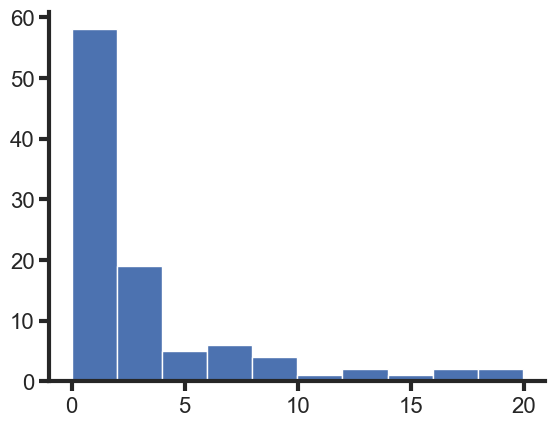

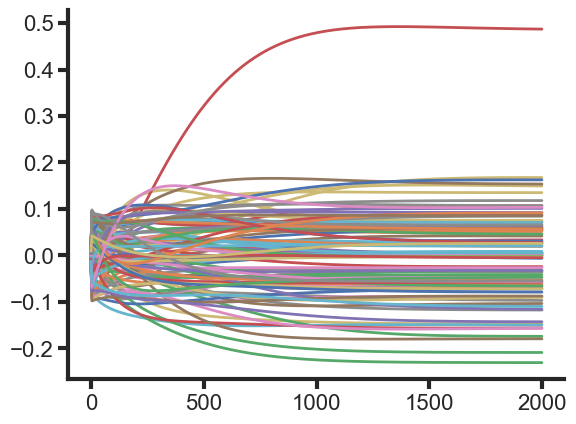

In [44]:
untrained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
trained = expirimental_RNN(
            input_size=1, hidden_size=100, output_size=1,
            dt=0.01, tau_array=tau_array,
            activation='tanh', tau_effect='decay',
            bias=True, sigma_in=0.01, sigma_re=0.01
        )
trained.load_state_dict(weights['rnn'][key][seed])

model = untrained

n_steps=2000
pulse_duration=5 
pulse_amp=2.0 
min_response_thresh=0.01

model.eval()

inputs = torch.zeros(1, n_steps, 1)
inputs[0, :pulse_duration, 0] = pulse_amp

h_trace = []
with torch.no_grad():
    hidden = model.init_hidden(batch_size=1)
    for t in range(n_steps):
        inp_t = inputs[:, t:t+1, :]
        hidden, _ = model(inp_t, hidden, noise=False)
        h_trace.append(hidden.squeeze(0).numpy())

h_trace = np.array(h_trace)        # (T, hidden_size)
post_pulse = h_trace[pulse_duration:, :]
t_axis = np.arange(len(post_pulse)) * model.dt

def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

taus = []
for i in range(model.hidden_size):
    signal = post_pulse[:, i]
    amp = np.max(np.abs(signal))
    
    # Skip neurons that don't respond
    if amp < min_response_thresh:
        taus.append(np.nan)
        continue
    
    try:
        A0 = signal[0] - signal[-1]
        tau0 = t_axis[np.argmax(np.abs(signal - signal[-1]) < amp/np.e) + 1]  # 1/e crossing
        tau0 = max(tau0, model.dt)  # avoid zero
        p0 = [A0, tau0, signal[-1]]
        bounds = ([- np.inf, model.dt, -np.inf], [np.inf, t_axis[-1], np.inf])
        popt, _ = curve_fit(exp_decay, t_axis, signal, p0=p0, bounds=bounds, maxfev=10000)
        taus.append(abs(popt[1]))
    except (RuntimeError, ValueError):
        taus.append(np.nan)

a, b = np.array(taus), h_trace
plt.hist(a)
plt.figure()
plt.plot(b);

eta 0 vs 0.1: n=23/30, 22/30 after dropping NaNs
  raw p=0.2159, corrected p=0.6477 → ns
eta 0 vs 0.1: raw p=0.2159, corrected p=0.6477 → ns
eta 0.1 vs 0.25: n=22/30, 25/30 after dropping NaNs
  raw p=0.0011, corrected p=0.0034 → **
eta 0.1 vs 0.25: raw p=0.0011, corrected p=0.0034 → **
eta 0.25 vs 0.5: n=25/30, 24/30 after dropping NaNs
  raw p=0.8026, corrected p=1.0000 → ns
eta 0.25 vs 0.5: raw p=0.8026, corrected p=1.0000 → ns


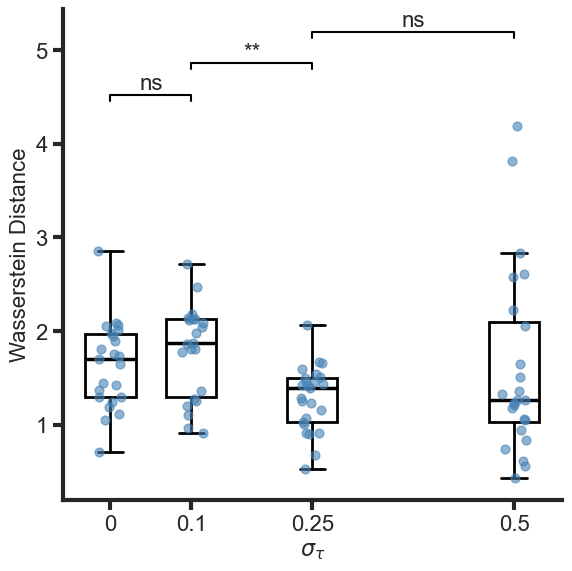

In [47]:
sns.set_theme(
    style="ticks",
    rc={
        "axes.spines.right": False,
        "axes.spines.top": False,
        
        # Axes and line tickness
        'axes.linewidth': 3,
        "lines.linewidth": 2,
        
        # Tick thickness
        "xtick.major.width": 3,
        "ytick.major.width": 3,

        # Tick length
        "xtick.major.size": 7,
        "ytick.major.size": 7,
        
        # Font size
        "font.size": 16,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 16,
    }
)

fig, ax = plt.subplots(figsize=(6, 6))

data   = [wasserstein_distances[eta] for eta in eta_list]
labels = [0, 0.1, 0.25, 0.5]
pos    = [0, 0.4, 1.0, 2.0]
widths = 0.15  # relative to pos spacing — tune as needed

# Strip NaNs per group for boxplot
clean_data = [np.array(d)[~np.isnan(d)] for d in data]

rng = np.random.default_rng(0)
for d, p in zip(data, pos):
    d_clean = np.array(d)
    mask = ~np.isnan(d_clean)
    jitter = rng.uniform(-0.06, 0.06, size=mask.sum())
    ax.scatter(p + jitter, d_clean[mask], color="steelblue", alpha=0.6, s=40, zorder=3)

ax.boxplot(
    clean_data,
    positions=pos,
    widths=0.25,          # was 0.15
    manage_ticks=False,
    patch_artist=True,
    boxprops=dict(facecolor="white", color="black", linewidth=2),      # added linewidth
    medianprops=dict(color="black", linewidth=2.5),                    # was 2
    whiskerprops=dict(color="black", linewidth=2),                     # added linewidth
    capprops=dict(color="black", linewidth=2),                         # added linewidth
    flierprops=dict(marker=""),
)

# Fixed significance label
def significance_label(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'ns'

n_comparisons = len(pos) - 1
y_max = max(max(d) for d in data)
bar_gap = y_max * 0.08

for i in range(n_comparisons):
    p1, p2 = pos[i], pos[i+1]
    
    d1 = np.array(data[i])
    d2 = np.array(data[i+1])
    
    d1_clean = d1[~np.isnan(d1)]
    d2_clean = d2[~np.isnan(d2)]
    
    print(f"eta {labels[i]} vs {labels[i+1]}: n={len(d1_clean)}/{len(d1)}, {len(d2_clean)}/{len(d2)} after dropping NaNs")
    
    _, p_val = mannwhitneyu(d1_clean, d2_clean, alternative='two-sided')
    p_corrected = min(p_val * n_comparisons, 1.0)
    label = significance_label(p_corrected)
    print(f"  raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")
    label = significance_label(p_corrected)
    print(f"eta {labels[i]} vs {labels[i+1]}: raw p={p_val:.4f}, corrected p={p_corrected:.4f} → {label}")

    bar_y = y_max + bar_gap * (i + 1)
    ax.plot([p1, p1, p2, p2], [bar_y - bar_gap*0.2, bar_y, bar_y, bar_y - bar_gap*0.2],
            color='black', linewidth=1.5)
    ax.text((p1 + p2) / 2, bar_y + bar_gap * 0.05, label,
            ha='center', va='bottom')

ax.set_xticks(pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Wasserstein Distance')
ax.set_xlabel(r'$\sigma_{\tau}$')

plt.tight_layout()
plt.show()